In [1]:
print("hello")

hello


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'numpy'

In [3]:
%pip install numpy pandas matplotlib

  Using cached numpy-2.5.2-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
  Using cached pandas-3.0.5-cp312-cp312-win_amd64.whl.metadata (19 kB)
  Using cached matplotlib-3.11.1-cp312-cp312-win_amd64.whl.metadata (80 kB)
  Using cached tzdata-2026.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp312-cp312-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp312-cp312-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp312-cp312-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached numpy-2.5.2-cp312-cp312-win_amd64.whl (12.5 MB)
Using cached pandas-3.0.5-cp312-cp312-win_amd64.whl (9.8 MB)
Using cached matplotlib-3.11.1-cp312-cp312-win_amd64.whl (9.3 MB)
Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-n


[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
data = np.loadtxt("data/d04_te.dat")
print(data.shape)

(960, 52)


In [6]:
columns = (
    [f"xmeas_{i}" for i in range(1, 42)]
    + [f"xmv_{i}" for i in range(1, 12)]
)

df = pd.DataFrame(data, columns=columns)

df.head()

,xmeas_1,xmeas_2,xmeas_3,xmeas_4,xmeas_5,xmeas_6,xmeas_7,xmeas_8,xmeas_9,xmeas_10,...,xmv_2,xmv_3,xmv_4,xmv_5,xmv_6,xmv_7,xmv_8,xmv_9,xmv_10,xmv_11
0,0.25185,3634.3,4527.3,9.3651,26.641,42.694,2705.6,75.649,120.40,0.33406,...,53.765,24.513,62.411,21.888,40.437,34.127,46.560,47.564,40.623,17.314
1,0.24938,3663.7,4494.0,9.3847,26.809,42.434,2705.4,74.546,120.43,0.33243,...,54.163,24.756,62.709,22.457,40.636,40.032,41.592,47.442,41.354,16.381
2,0.25162,3643.7,4484.5,9.3197,27.319,42.231,2704.0,74.461,120.38,0.33558,...,54.277,24.543,59.878,22.143,40.250,35.760,47.191,47.561,40.754,22.871
3,0.25019,3648.7,4488.4,9.3639,26.955,42.573,2703.9,75.036,120.43,0.33855,...,54.230,24.684,60.546,22.027,39.888,35.828,47.661,47.351,41.427,15.460
4,0.24848,3658.1,4543.2,9.3925,26.920,42.278,2705.6,75.737,120.38,0.35306,...,54.495,24.383,60.414,22.333,41.991,43.347,47.619,47.390,40.140,17.464


In [7]:
print(df.shape)
print(df.isnull().sum().sum())

(960, 52)
0


In [8]:
df["time_h"] = np.arange(len(df)) * 3 / 60

In [9]:
df[["time_h", "xmeas_9"]].head()

,time_h,xmeas_9
0,0.00,120.40
1,0.05,120.43
2,0.10,120.38
3,0.15,120.43
4,0.20,120.38


In [10]:
df["xmeas_9"].describe()

count    960.000000
mean     120.400583
std        0.019824
min      120.340000
25%      120.390000
50%      120.400000
75%      120.410000
max      120.600000
Name: xmeas_9, dtype: float64

In [11]:
df.loc[155:165, ["time_h", "xmeas_9"]]

,time_h,xmeas_9
155,7.75,120.41
156,7.80,120.38
157,7.85,120.39
158,7.90,120.38
159,7.95,120.37
160,8.00,120.60
161,8.05,120.40
162,8.10,120.45
163,8.15,120.44
164,8.20,120.40


In [12]:
df.loc[155:165, ["time_h", "xmeas_9", "xmv_10"]]

,time_h,xmeas_9,xmv_10
155,7.75,120.41,41.991
156,7.80,120.38,40.444
157,7.85,120.39,41.804
158,7.90,120.38,40.819
159,7.95,120.37,40.694
160,8.00,120.60,47.248
161,8.05,120.40,43.966
162,8.10,120.45,45.329
163,8.15,120.44,45.103
164,8.20,120.40,44.911


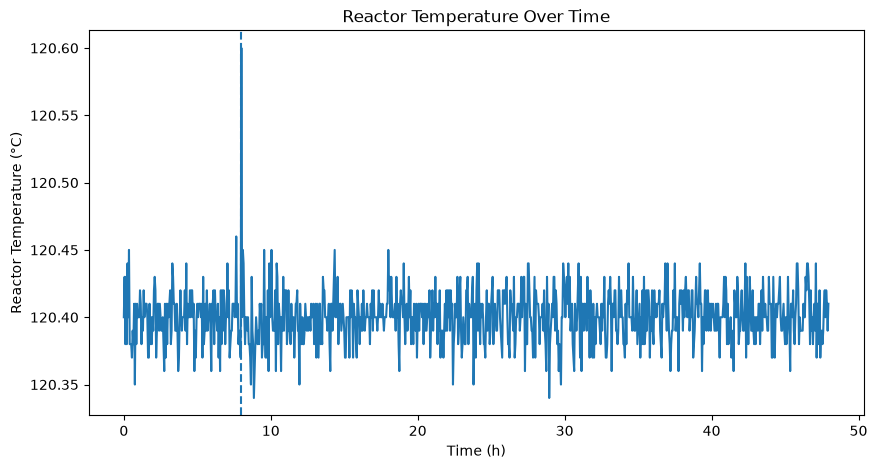

In [14]:
plt.figure(figsize=(10, 5))

plt.plot(df["time_h"], df["xmeas_9"])

plt.axvline(8, linestyle="--")

plt.xlabel("Time (h)")
plt.ylabel("Reactor Temperature (°C)")
plt.title("Reactor Temperature Over Time")

plt.savefig("images/01_reactor_temperature.png", dpi=150, bbox_inches="tight")

plt.show()

In [15]:
df["temp_ma_30m"] = df["xmeas_9"].rolling(10).mean()

In [16]:
df[["time_h", "xmeas_9", "temp_ma_30m"]].head(15)

,time_h,xmeas_9,temp_ma_30m
0,0.00,120.40,NaN
1,0.05,120.43,NaN
2,0.10,120.38,NaN
3,0.15,120.43,NaN
4,0.20,120.38,NaN
5,0.25,120.44,NaN
6,0.30,120.40,NaN
7,0.35,120.45,NaN
8,0.40,120.38,NaN
9,0.45,120.38,120.407


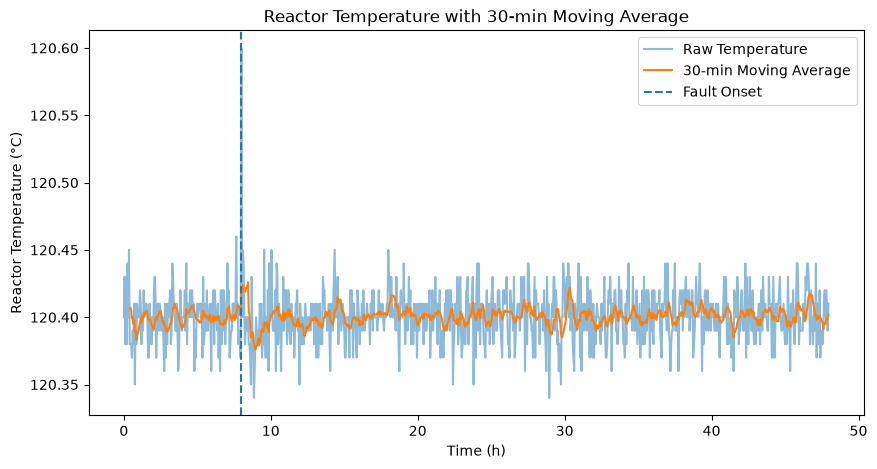

In [18]:
plt.figure(figsize=(10, 5))

plt.plot(
    df["time_h"],
    df["xmeas_9"],
    alpha=0.5,
    label="Raw Temperature"
)

plt.plot(
    df["time_h"],
    df["temp_ma_30m"],
    label="30-min Moving Average"
)

plt.axvline(8, linestyle="--", label="Fault Onset")

plt.xlabel("Time (h)")
plt.ylabel("Reactor Temperature (°C)")
plt.title("Reactor Temperature with 30-min Moving Average")

plt.legend()

plt.savefig("images/02_moving_average.png", dpi=150, bbox_inches="tight")

plt.show()

In [19]:
df["temp_change"] = df["xmeas_9"].diff()

In [20]:
df.loc[155:165, ["time_h", "xmeas_9", "temp_change"]]

,time_h,xmeas_9,temp_change
155,7.75,120.41,0.01
156,7.80,120.38,-0.03
157,7.85,120.39,0.01
158,7.90,120.38,-0.01
159,7.95,120.37,-0.01
160,8.00,120.60,0.23
161,8.05,120.40,-0.20
162,8.10,120.45,0.05
163,8.15,120.44,-0.01
164,8.20,120.40,-0.04


In [21]:
df["abs_temp_change"] = df["temp_change"].abs()

df.nlargest(5, "abs_temp_change")[
    ["time_h", "xmeas_9", "temp_change"]
]

,time_h,xmeas_9,temp_change
160,8.00,120.60,0.23
161,8.05,120.40,-0.20
174,8.70,120.43,0.08
476,23.80,120.35,-0.08
198,9.90,120.44,0.08


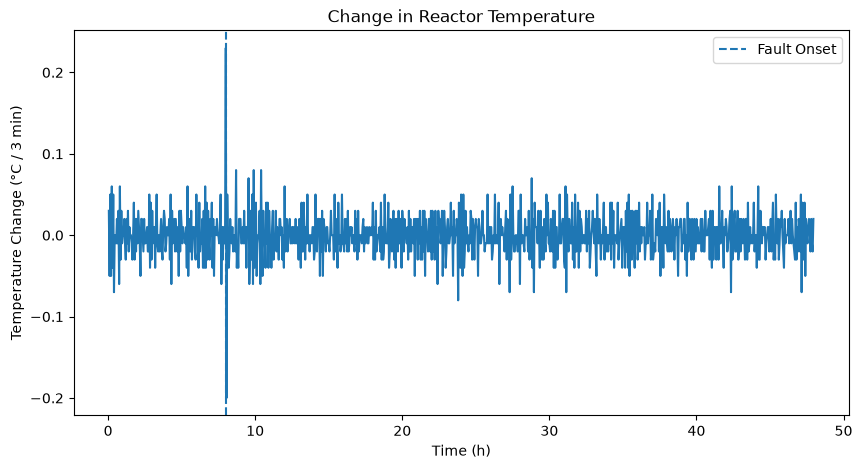

In [23]:
plt.figure(figsize=(10, 5))

plt.plot(df["time_h"], df["temp_change"])

plt.axvline(8, linestyle="--", label="Fault Onset")

plt.xlabel("Time (h)")
plt.ylabel("Temperature Change (°C / 3 min)")
plt.title("Change in Reactor Temperature")

plt.legend()

plt.savefig("images/03_temperature_change.png", dpi=150, bbox_inches="tight")

plt.show()

In [24]:
fault_zone = df[
    (df["time_h"] >= 7.5) &
    (df["time_h"] <= 10)
]

In [25]:
fault_zone[["time_h", "xmeas_9", "xmv_10"]].head()

,time_h,xmeas_9,xmv_10
150,7.50,120.41,41.748
151,7.55,120.40,40.700
152,7.60,120.41,42.296
153,7.65,120.46,42.060
154,7.70,120.40,41.412


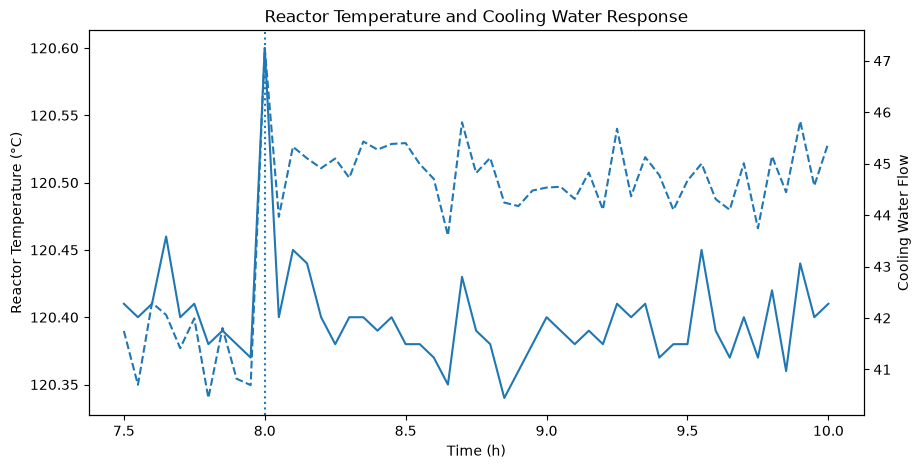

In [27]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(
    fault_zone["time_h"],
    fault_zone["xmeas_9"],
    label="Reactor Temperature"
)

ax1.set_xlabel("Time (h)")
ax1.set_ylabel("Reactor Temperature (°C)")

ax2 = ax1.twinx()

ax2.plot(
    fault_zone["time_h"],
    fault_zone["xmv_10"],
    linestyle="--",
    label="Cooling Water Flow"
)

ax2.set_ylabel("Cooling Water Flow")

ax1.axvline(8, linestyle=":")

plt.title("Reactor Temperature and Cooling Water Response")

plt.savefig("images/04_control_response.png", dpi=150, bbox_inches="tight")

plt.show()

In [29]:
normal = df[df["time_h"] < 8]
fault = df[df["time_h"] >= 8]

normal_flow_mean = normal["xmv_10"].mean()
fault_flow_mean = fault["xmv_10"].mean()

print("Normal cooling water flow mean:", normal_flow_mean)
print("Fault cooling water flow mean:", fault_flow_mean)

increase_rate = (
    (fault_flow_mean - normal_flow_mean)
    / normal_flow_mean
    * 100
)

print("Increase rate:", increase_rate, "%")

Normal cooling water flow mean: 41.142424999999996
Fault cooling water flow mean: 44.892222499999995
Increase rate: 9.114186876442018 %


In [30]:
flow_before = df.loc[159, "xmv_10"]
flow_fault = df.loc[160, "xmv_10"]

flow_change_rate = (
    (flow_fault - flow_before)
    / flow_before
    * 100
)

print("Before fault:", flow_before)
print("At fault:", flow_fault)
print("Immediate increase rate:", flow_change_rate, "%")

Before fault: 40.694
At fault: 47.248
Immediate increase rate: 16.1055683884602 %


In [32]:
df["temp_std_60m"] = df["xmeas_9"].rolling(20).std()
df[["time_h", "xmeas_9", "temp_std_60m"]].head(25)

,time_h,xmeas_9,temp_std_60m
0,0.00,120.40,NaN
1,0.05,120.43,NaN
2,0.10,120.38,NaN
3,0.15,120.43,NaN
4,0.20,120.38,NaN
5,0.25,120.44,NaN
6,0.30,120.40,NaN
7,0.35,120.45,NaN
8,0.40,120.38,NaN
9,0.45,120.38,NaN


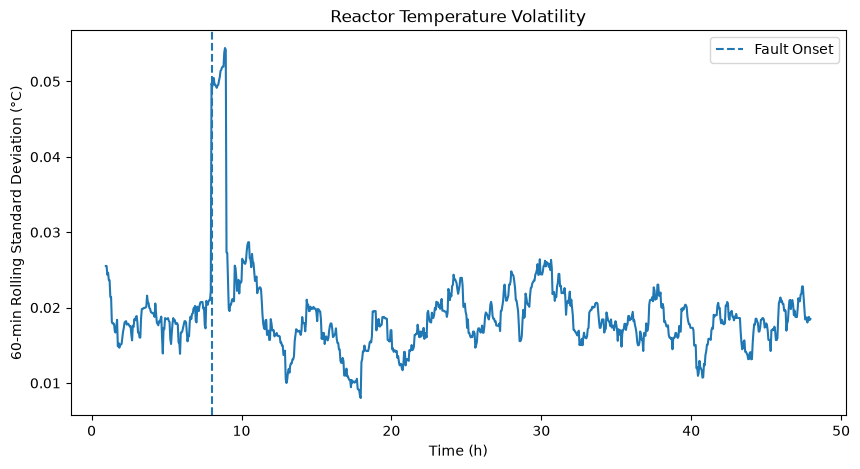

In [34]:
plt.figure(figsize=(10, 5))

plt.plot(
    df["time_h"],
    df["temp_std_60m"]
)

plt.axvline(
    8,
    linestyle="--",
    label="Fault Onset"
)

plt.xlabel("Time (h)")
plt.ylabel("60-min Rolling Standard Deviation (°C)")
plt.title("Reactor Temperature Volatility")

plt.legend()

plt.savefig("images/05_temperature_volatility.png", dpi=150, bbox_inches="tight")

plt.show()

In [35]:
df.loc[155:180, ["time_h", "xmeas_7", "xmeas_9"]]

,time_h,xmeas_7,xmeas_9
155,7.75,2708.6,120.41
156,7.80,2710.2,120.38
157,7.85,2710.8,120.39
158,7.90,2708.9,120.38
159,7.95,2708.2,120.37
160,8.00,2711.5,120.60
161,8.05,2714.8,120.40
162,8.10,2716.6,120.45
163,8.15,2716.3,120.44
164,8.20,2712.3,120.40


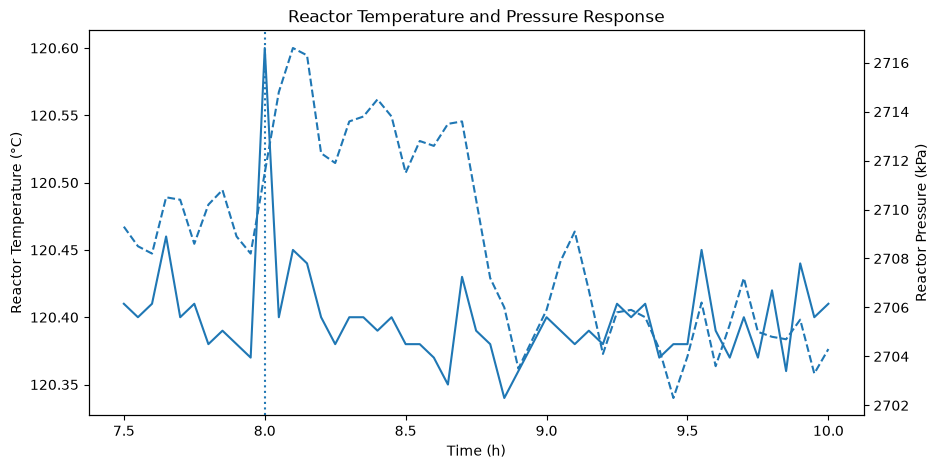

In [36]:
pressure_zone = df[
    (df["time_h"] >= 7.5) &
    (df["time_h"] <= 10)
]

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(
    pressure_zone["time_h"],
    pressure_zone["xmeas_9"],
    label="Reactor Temperature"
)

ax1.set_xlabel("Time (h)")
ax1.set_ylabel("Reactor Temperature (°C)")

ax2 = ax1.twinx()

ax2.plot(
    pressure_zone["time_h"],
    pressure_zone["xmeas_7"],
    linestyle="--",
    label="Reactor Pressure"
)

ax2.set_ylabel("Reactor Pressure (kPa)")

ax1.axvline(8, linestyle=":")

plt.title("Reactor Temperature and Pressure Response")

plt.show()

In [37]:
pressure_peak = pressure_zone.loc[
    pressure_zone["xmeas_7"].idxmax(),
    ["time_h", "xmeas_7"]
]

pressure_peak

time_h        8.1
xmeas_7    2716.6
Name: 162, dtype: float64

In [38]:
temp_peak_time = df.loc[df["xmeas_9"].idxmax(), "time_h"]
pressure_peak_time = pressure_peak["time_h"]

lag_min = (pressure_peak_time - temp_peak_time) * 60

print("Temperature peak time:", temp_peak_time, "h")
print("Pressure peak time:", pressure_peak_time, "h")
print("Lag:", lag_min, "min")

Temperature peak time: 8.0 h
Pressure peak time: 8.1 h
Lag: 5.999999999999979 min


In [39]:
df["pressure_std_60m"] = df["xmeas_7"].rolling(20).std()

In [40]:
normal_pressure_std = normal["xmeas_7"].std()
fault_pressure_std = fault["xmeas_7"].std()

print("Normal pressure std:", normal_pressure_std)
print("Fault pressure std:", fault_pressure_std)

Normal pressure std: 5.133953446168107
Fault pressure std: 7.80987787936619


In [41]:
pressure_std_increase = (
    (fault_pressure_std - normal_pressure_std)
    / normal_pressure_std
    * 100
)

print("Pressure std increase:", round(pressure_std_increase, 1), "%")

Pressure std increase: 52.1 %


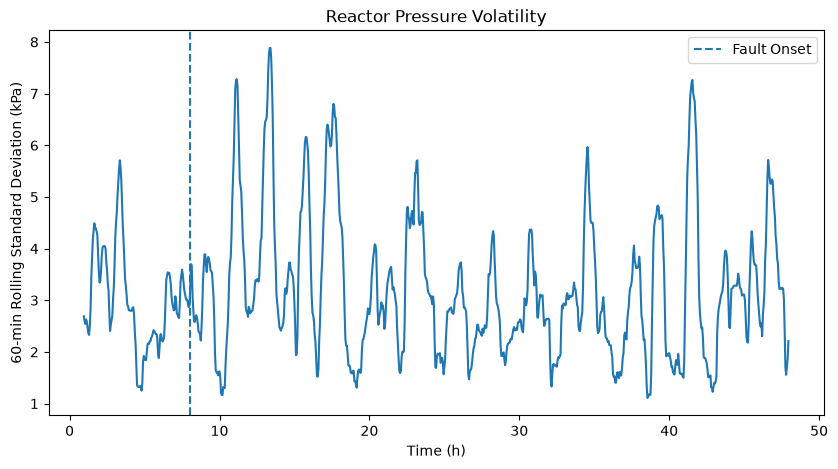

In [43]:
plt.figure(figsize=(10, 5))

plt.plot(
    df["time_h"],
    df["pressure_std_60m"]
)

plt.axvline(
    8,
    linestyle="--",
    label="Fault Onset"
)

plt.xlabel("Time (h)")
plt.ylabel("60-min Rolling Standard Deviation (kPa)")
plt.title("Reactor Pressure Volatility")

plt.legend()

plt.savefig("images/06_pressure_volatility.png", dpi=150, bbox_inches="tight")

plt.show()